In [107]:
import pandas as pd
import os

In [108]:
df = pd.read_csv('electricity_kosovo.csv')
df

,Datetime (UTC),Country,Zone name,Zone id,Carbon intensity gCO₂eq/kWh (direct),Carbon intensity gCO₂eq/kWh (Life cycle),Carbon-free energy percentage (CFE%),Renewable energy percentage (RE%),Data source,Data estimated,Data estimation method
0,2025-01-01T00:00:00.000000,Kosovo,Kosovo,XK,612.16,667.76,17.69,13.36,entsoe.eu,False,NaN
1,2025-01-01T01:00:00.000000,Kosovo,Kosovo,XK,641.81,699.26,13.88,9.22,entsoe.eu,False,NaN
2,2025-01-01T02:00:00.000000,Kosovo,Kosovo,XK,643.12,701.16,13.56,8.28,entsoe.eu,False,NaN
3,2025-01-01T03:00:00.000000,Kosovo,Kosovo,XK,641.53,699.58,13.67,8.54,entsoe.eu,False,NaN
4,2025-01-01T04:00:00.000000,Kosovo,Kosovo,XK,647.20,705.28,13.03,8.30,entsoe.eu,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...
8755,2025-12-31T19:00:00.000000,Kosovo,Kosovo,XK,561.09,609.44,25.64,24.71,entsoe.eu,False,NaN
8756,2025-12-31T20:00:00.000000,Kosovo,Kosovo,XK,604.28,656.04,19.80,18.43,entsoe.eu,False,NaN
8757,2025-12-31T21:00:00.000000,Kosovo,Kosovo,XK,597.68,648.91,20.79,19.65,entsoe.eu,False,NaN
8758,2025-12-31T22:00:00.000000,Kosovo,Kosovo,XK,600.28,652.40,20.10,18.69,entsoe.eu,False,NaN


In [109]:
df.dtypes

Datetime (UTC)                               object
Country                                      object
Zone name                                    object
Zone id                                      object
Carbon intensity gCO₂eq/kWh (direct)        float64
Carbon intensity gCO₂eq/kWh (Life cycle)    float64
Carbon-free energy percentage (CFE%)        float64
Renewable energy percentage (RE%)           float64
Data source                                  object
Data estimated                                 bool
Data estimation method                       object
dtype: object

In [110]:
df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

In [111]:
len(df.columns)

11

In [112]:
df[df.isnull().any(axis=1)].reset_index()

,index,Datetime (UTC),Country,Zone name,Zone id,Carbon intensity gCO₂eq/kWh (direct),Carbon intensity gCO₂eq/kWh (Life cycle),Carbon-free energy percentage (CFE%),Renewable energy percentage (RE%),Data source,Data estimated,Data estimation method
0,0,2025-01-01 00:00:00,Kosovo,Kosovo,XK,612.16,667.76,17.69,13.36,entsoe.eu,False,NaN
1,1,2025-01-01 01:00:00,Kosovo,Kosovo,XK,641.81,699.26,13.88,9.22,entsoe.eu,False,NaN
2,2,2025-01-01 02:00:00,Kosovo,Kosovo,XK,643.12,701.16,13.56,8.28,entsoe.eu,False,NaN
3,3,2025-01-01 03:00:00,Kosovo,Kosovo,XK,641.53,699.58,13.67,8.54,entsoe.eu,False,NaN
4,4,2025-01-01 04:00:00,Kosovo,Kosovo,XK,647.20,705.28,13.03,8.30,entsoe.eu,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
8753,8755,2025-12-31 19:00:00,Kosovo,Kosovo,XK,561.09,609.44,25.64,24.71,entsoe.eu,False,NaN
8754,8756,2025-12-31 20:00:00,Kosovo,Kosovo,XK,604.28,656.04,19.80,18.43,entsoe.eu,False,NaN
8755,8757,2025-12-31 21:00:00,Kosovo,Kosovo,XK,597.68,648.91,20.79,19.65,entsoe.eu,False,NaN
8756,8758,2025-12-31 22:00:00,Kosovo,Kosovo,XK,600.28,652.40,20.10,18.69,entsoe.eu,False,NaN


In [113]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Data estimation method                      99.977169
Datetime (UTC)                               0.000000
Country                                      0.000000
Zone name                                    0.000000
Zone id                                      0.000000
Carbon intensity gCO₂eq/kWh (direct)         0.000000
Carbon intensity gCO₂eq/kWh (Life cycle)     0.000000
Carbon-free energy percentage (CFE%)         0.000000
Renewable energy percentage (RE%)            0.000000
Data source                                  0.000000
Data estimated                               0.000000
dtype: float64

In [114]:
df.isnull().sum()
df.duplicated().sum()

0

In [115]:
important_cols = [
    'Carbon intensity gCO₂eq/kWh (direct)',
    'Carbon intensity gCO₂eq/kWh (Life cycle)',
    'Carbon-free energy percentage (CFE%)',
    'Renewable energy percentage (RE%)'
]

df[important_cols].isnull().sum()

Carbon intensity gCO₂eq/kWh (direct)        0
Carbon intensity gCO₂eq/kWh (Life cycle)    0
Carbon-free energy percentage (CFE%)        0
Renewable energy percentage (RE%)           0
dtype: int64

In [116]:
df.columns

Index(['Datetime (UTC)', 'Country', 'Zone name', 'Zone id',
       'Carbon intensity gCO₂eq/kWh (direct)',
       'Carbon intensity gCO₂eq/kWh (Life cycle)',
       'Carbon-free energy percentage (CFE%)',
       'Renewable energy percentage (RE%)', 'Data source', 'Data estimated',
       'Data estimation method'],
      dtype='object')

In [117]:
daily = df.resample('D', on='Datetime (UTC)').mean(numeric_only=True)

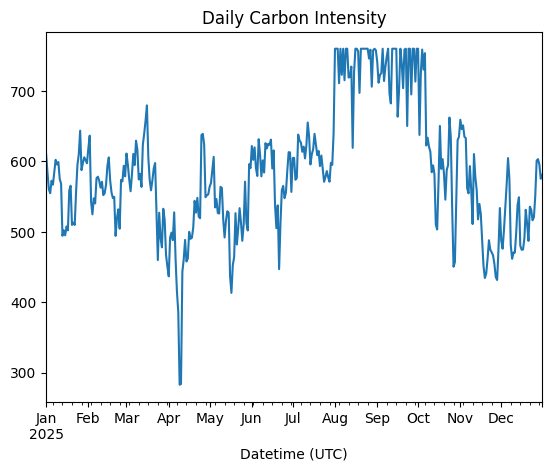

In [118]:
import matplotlib.pyplot as plt

daily['Carbon intensity gCO₂eq/kWh (direct)'].plot()
plt.title("Daily Carbon Intensity")
plt.show()

In [119]:
df = df.drop_duplicates()
df = df.drop(columns=['Data source', 'Data estimated', 'Data estimation method'])

In [120]:
df.columns

Index(['Datetime (UTC)', 'Country', 'Zone name', 'Zone id',
       'Carbon intensity gCO₂eq/kWh (direct)',
       'Carbon intensity gCO₂eq/kWh (Life cycle)',
       'Carbon-free energy percentage (CFE%)',
       'Renewable energy percentage (RE%)'],
      dtype='object')

In [121]:
df['hour'] = df['Datetime (UTC)'].dt.hour
df['day'] = df['Datetime (UTC)'].dt.day
df['month'] = df['Datetime (UTC)'].dt.month
df['weekday'] = df['Datetime (UTC)'].dt.weekday

In [122]:
col = 'Carbon intensity gCO₂eq/kWh (direct)'

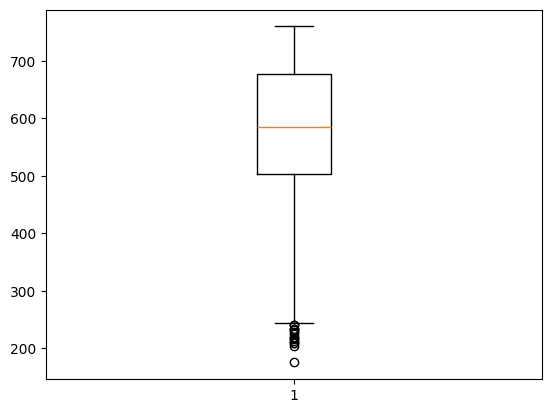

In [123]:
import matplotlib.pyplot as plt

plt.boxplot(df[col])
plt.show()

In [124]:
df_original = df.copy()

df_original.to_csv("df_inc_outliers.csv", index=False)

In [125]:
Q1 = df[col].quantile(0.30)
Q3 = df[col].quantile(0.70)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: 319.51599999999996
Upper bound: 856.092


In [126]:
df['is_outlier'] = ((df[col] < lower_bound) | (df[col] > upper_bound))

In [127]:
outlier_percentage = df['is_outlier'].mean() * 100
print(f"Outliers: {outlier_percentage:.2f}%")

Outliers: 0.81%


In [128]:
df_no_outliers = df[df['is_outlier'] == False].copy()

In [129]:

df_no_outliers.to_csv("df_no_outliers.csv", index=False)

In [130]:
outliers = df[df['is_outlier'] == True]

outliers.to_csv("outliers.csv", index=False)

In [131]:
daily_no_outliers = df_no_outliers.resample('D', on='Datetime (UTC)').mean(numeric_only=True)

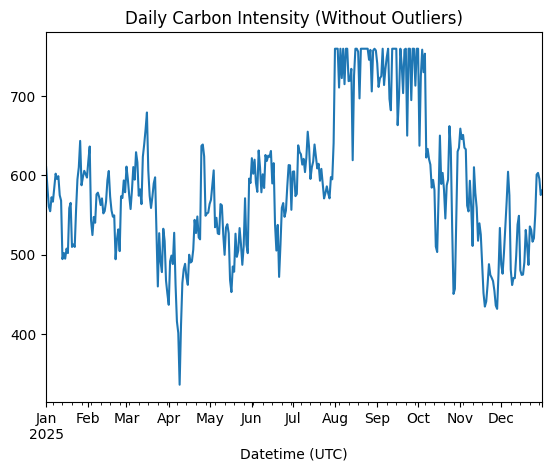

In [132]:
import matplotlib.pyplot as plt

daily_no_outliers['Carbon intensity gCO₂eq/kWh (direct)'].plot()
plt.title("Daily Carbon Intensity (Without Outliers)")
plt.show()